In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import os


print(os.getcwd())


c:\Users\astau\OneDrive\Documents\GitHub\musa5500-python-final\notebooks


In [3]:
os.chdir(r"C:\Users\astau\OneDrive\Documents\GitHub\musa5500-python-final")


In [4]:
citylimits = gpd.read_file("data/City_Limits.geojson")
neighborhoods = gpd.read_file("data/philly_neighborhoods.geojson")

In [5]:
ep = neighborhoods[neighborhoods["NAME"].str.contains("Passyunk Square", case=False)]


ValueError: aspect must be finite and positive 

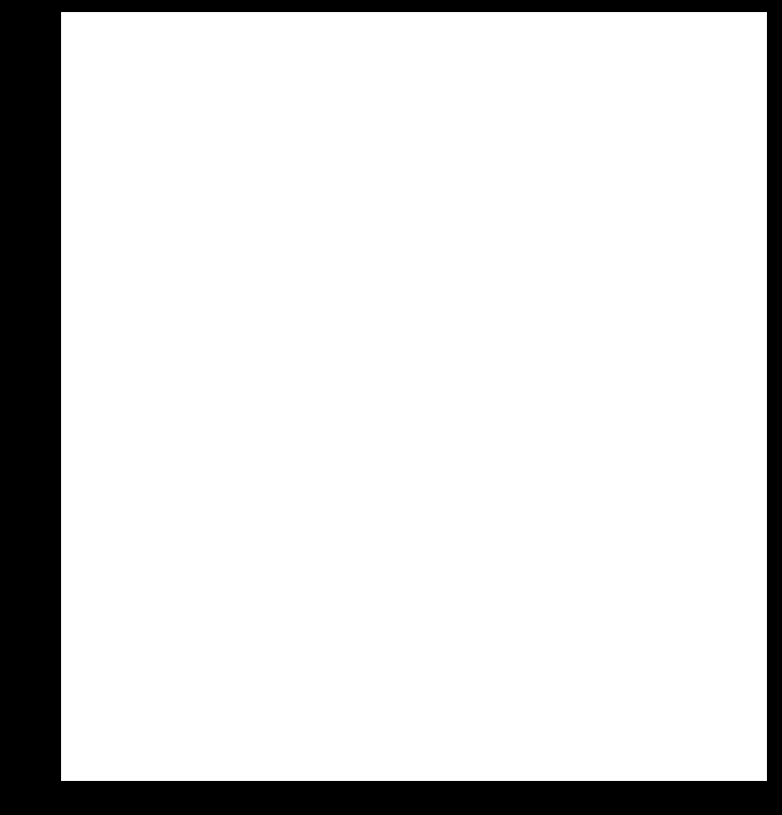

In [6]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")

# Plot city outline
citylimits.boundary.plot(ax=ax, color="white", linewidth=1.2)

# Highlight East Passyunk
ep.plot(ax=ax, color="#FF7F5055", edgecolor="#FF7F50", linewidth=2)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("locator_map.png", dpi=300, facecolor="black")
plt.show()


In [ ]:
import osmnx as ox

# Convert city boundary to a polygon for OSMnx
city_poly = citylimits.to_crs(4326).geometry.unary_union
# Download major roads only
tags = {"highway": True}  # all OSM road types
roads = ox.geometries_from_polygon(city_poly, tags)
water = ox.geometries_from_polygon(city_poly, {"natural": "water"})

south_philly = ox.geocode_to_gdf("South Philadelphia, Philadelphia, PA")

buildings = ox.features_from_polygon(
    south_philly.geometry[0],
    tags={"building": True}
)

C:\Users\astau\AppData\Local\Temp\ipykernel_44224\2290865205.py:7: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  roads = ox.geometries_from_polygon(city_poly, tags)
C:\Users\astau\AppData\Local\Temp\ipykernel_44224\2290865205.py:8: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  water = ox.geometries_from_polygon(city_poly, {"natural": "water"})


In [ ]:
fig, ax = plt.subplots(figsize=(10, 14))

# City outline (use your local GeoJSON)
citylimits.boundary.plot(ax=ax, color="white", linewidth=1.5)

# South Philly highlight
south_philly.boundary.plot(ax=ax, color="#4fa4ff", linewidth=2)

# Big buildings
big_buildings.boundary.plot(ax=ax, color="#666666", linewidth=0.2)

plt.axis("off")
plt.show()


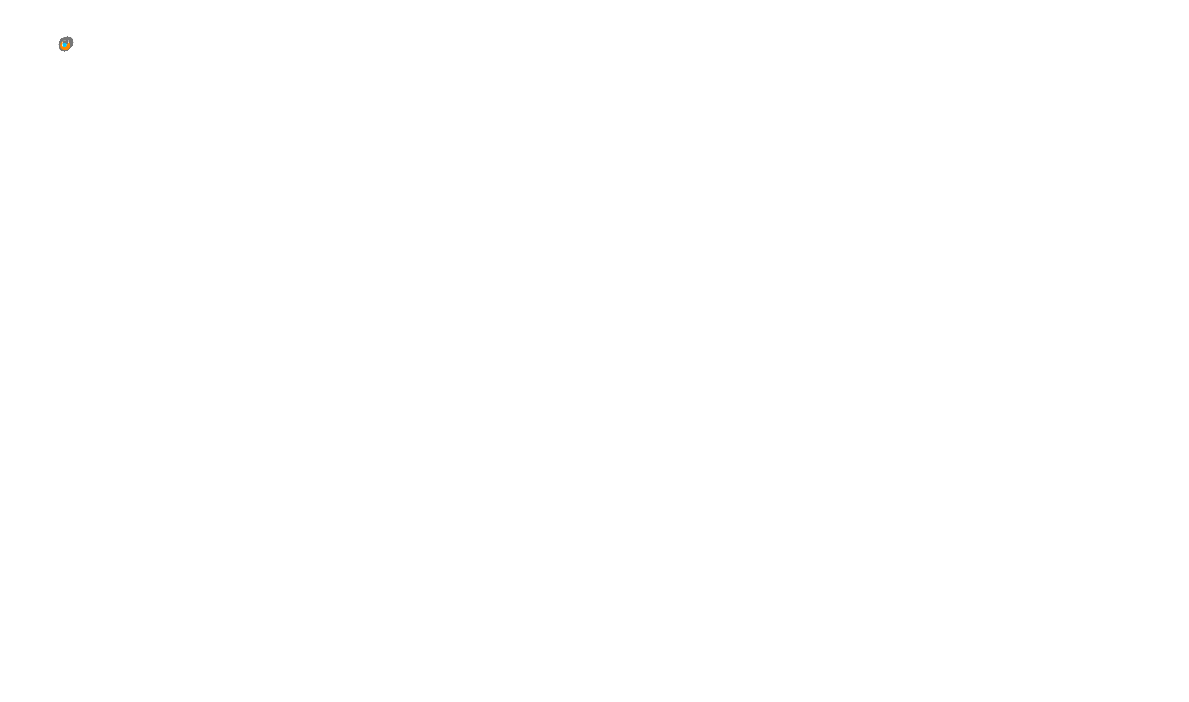

In [ ]:
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_facecolor("black")

# --- City outline ---
citylimits.to_crs(3857).boundary.plot(ax=ax, color="white", linewidth=1.5)

# --- Roads (geometries, not graph) ---
roads.to_crs(3857).plot(ax=ax, color="#777777", linewidth=0.5)


# --- South Philly boundary ---
south_philly.to_crs(3857).boundary.plot(ax=ax, color="#00ccff", linewidth=2)

# Highlight East Passyunk
ep.plot(ax=ax, color="#FF7F5055", edgecolor="#BB286D", linewidth=2)

# --- Buildings ---
buildings.to_crs(3857).plot(ax=ax, color="#ff8800", linewidth=0.3)

plt.axis("off")
plt.tight_layout()
plt.show()

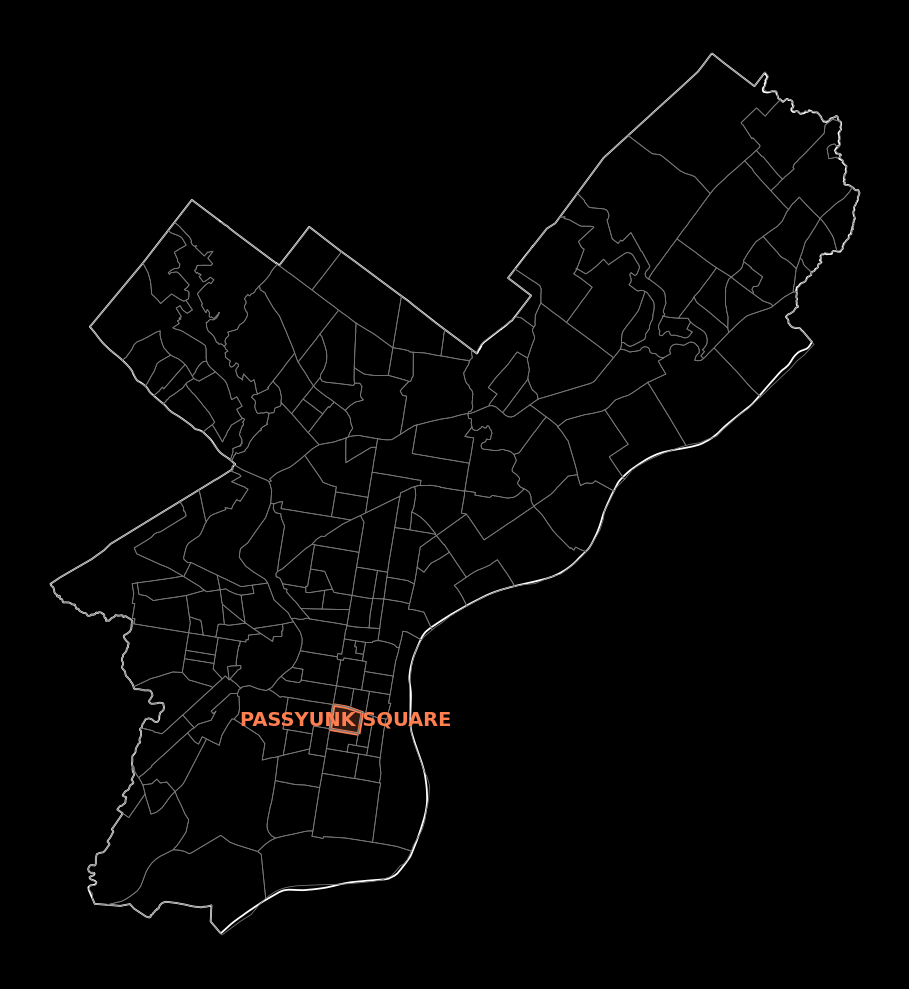

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load data
citylimits = gpd.read_file("data/City_Limits.geojson")
neighborhoods = gpd.read_file("data/philly_neighborhoods.geojson")

# Select only Passyunk Square
ep = neighborhoods[neighborhoods["NAME"] == "PASSYUNK_SQUARE"]

# Reproject everything
citylimits = citylimits.to_crs(3857)
neighborhoods = neighborhoods.to_crs(3857)
ep = ep.to_crs(3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")

# City outline
citylimits.boundary.plot(ax=ax, color="white", linewidth=1.3)

# Neighborhood internal boundaries (brighter now)
neighborhoods.boundary.plot(ax=ax, color="#777777", linewidth=0.6)

# Highlight Passyunk Square
ep.plot(ax=ax, color="#FF7F5035", edgecolor="#FF7F50", linewidth=2.5)

# Label
centroid = ep.geometry.centroid.iloc[0]
ax.text(
    centroid.x,
    centroid.y,
    "PASSYUNK SQUARE",
    color="#FF7F50",
    fontsize=14,
    weight="bold",
    ha="center",
    va="center",
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("locator_passyunk_only.png", dpi=300, facecolor="black", bbox_inches="tight")
plt.show()


AttributeError: 'NoneType' object has no attribute '_get_renderer'

<Figure size 1200x1200 with 3 Axes>

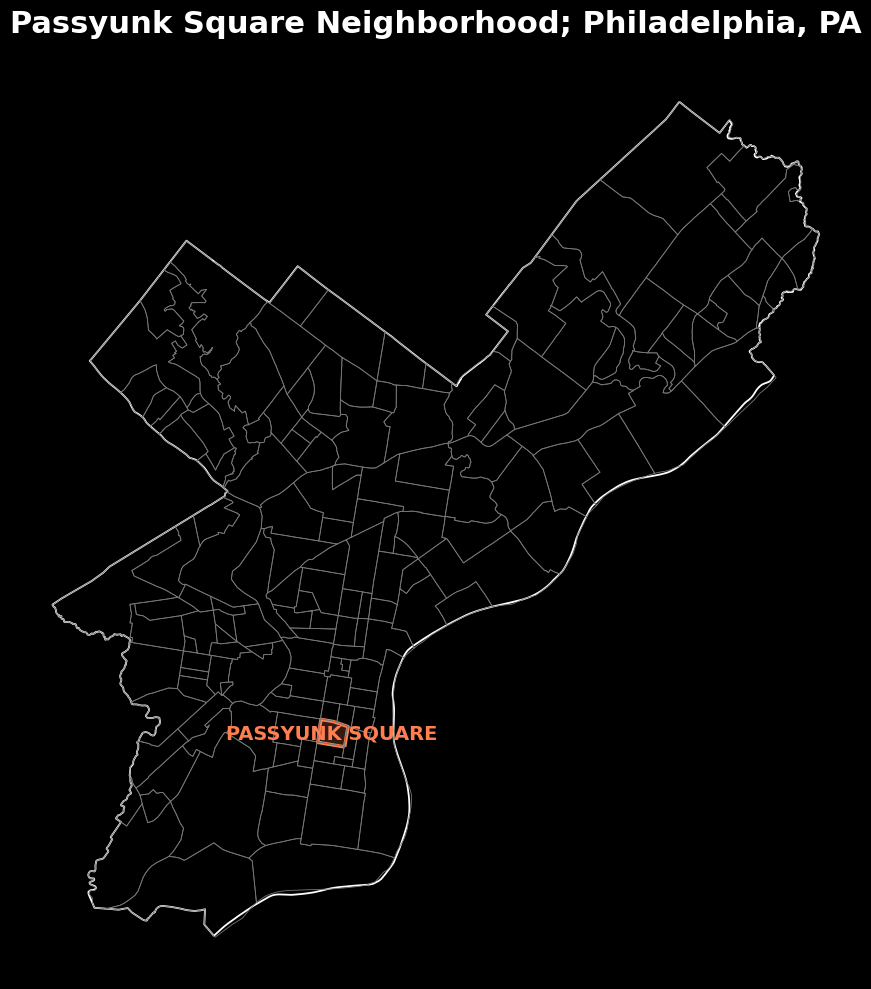

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load data
citylimits = gpd.read_file("data/City_Limits.geojson")
neighborhoods = gpd.read_file("data/philly_neighborhoods.geojson")

# Select only Passyunk Square
ep = neighborhoods[neighborhoods["NAME"] == "PASSYUNK_SQUARE"]

# Reproject everything
citylimits = citylimits.to_crs(3857)
neighborhoods = neighborhoods.to_crs(3857)
ep = ep.to_crs(3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")

# Title + subtitle
plt.title(
    "Passyunk Square Neighborhood; Philadelphia, PA",
    fontsize=22,
    color="white",
    weight="bold",
    pad=20
)

# City outline
citylimits.boundary.plot(ax=ax, color="white", linewidth=1.3)

# Neighborhood internal boundaries
neighborhoods.boundary.plot(ax=ax, color="#777777", linewidth=0.6)

# Highlight Passyunk Square
ep.plot(ax=ax, color="#FF7F5035", edgecolor="#FF7F50", linewidth=2.5)

# Label inside the polygon
centroid = ep.geometry.centroid.iloc[0]
ax.text(
    centroid.x,
    centroid.y,
    "PASSYUNK SQUARE",
    color="#FF7F50",
    fontsize=14,
    weight="bold",
    ha="center",
    va="center",
)

# Remove axes
ax.set_axis_off()

plt.tight_layout()
plt.savefig("locator_passyunk_only_titled.png",
            dpi=300,
            facecolor="black",
            bbox_inches="tight")
plt.show()


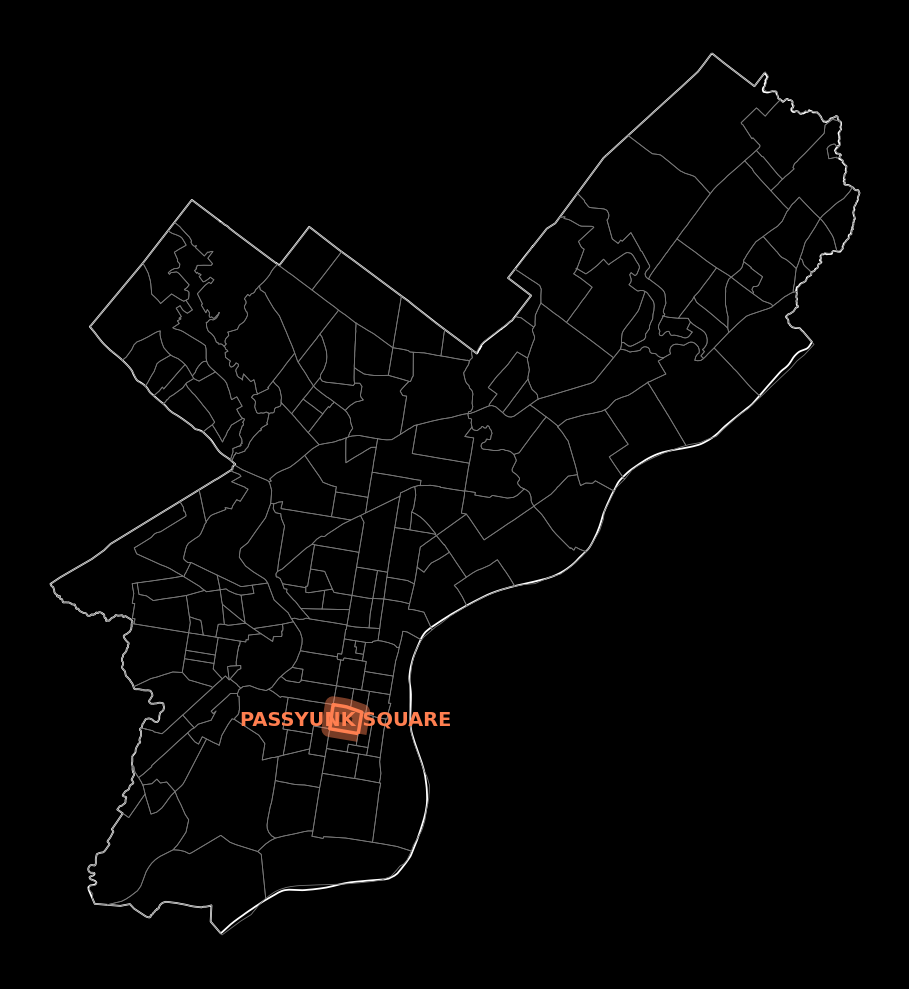

In [ ]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10,10), facecolor="black")

# Base outlines
citylimits.boundary.plot(ax=ax, color="white", linewidth=1.3)
neighborhoods.boundary.plot(ax=ax, color="#777777", linewidth=0.6)

# --- GLOW EFFECT ---
glow = pe.withStroke(linewidth=12, foreground="#FF7F5077")
ep.boundary.plot(ax=ax, color="#FF7F50", linewidth=2.5, path_effects=[glow])

# Color fill
ep.plot(ax=ax, color="#FF7F5035")

# Label
c = ep.geometry.centroid.iloc[0]
ax.text(
    c.x, c.y, "PASSYUNK SQUARE",
    color="#FF7F50", fontsize=14, weight="bold",
    ha="center", va="center",
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("locator_passyunk_glow.png", dpi=300, facecolor="black")
plt.show()

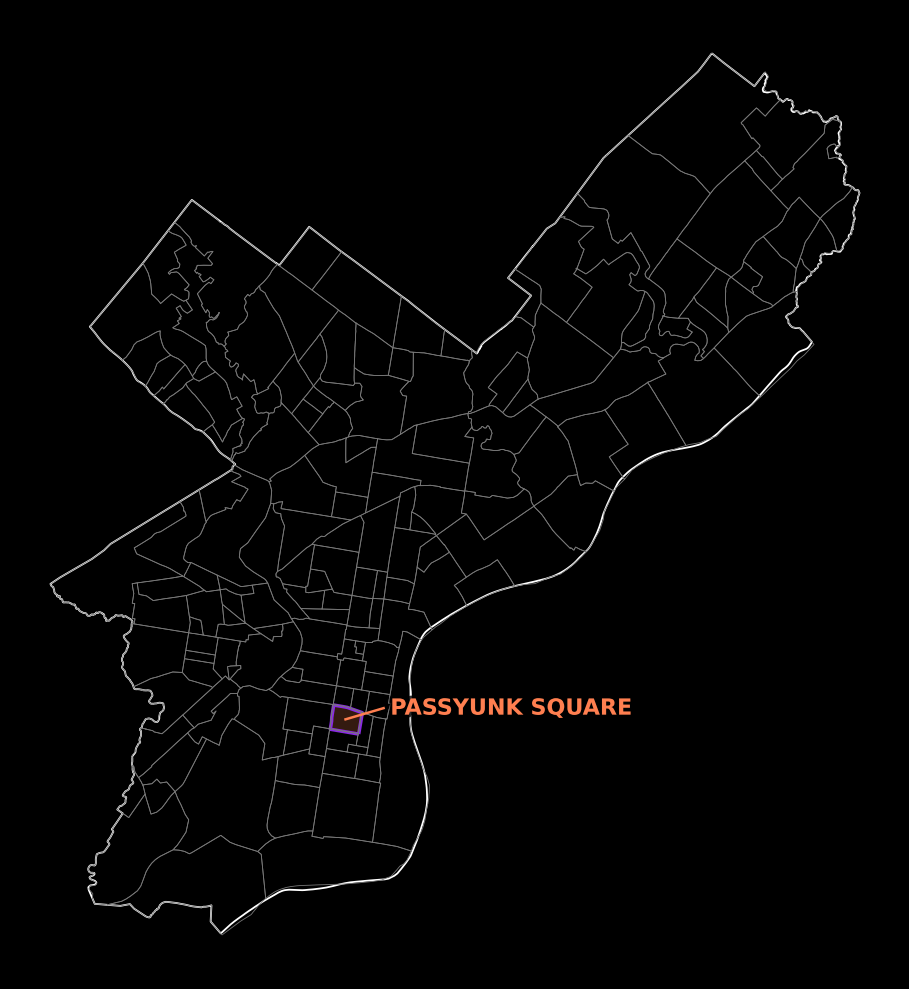

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects

# Load data
citylimits = gpd.read_file("data/City_Limits.geojson")
neighborhoods = gpd.read_file("data/philly_neighborhoods.geojson")

# Select only Passyunk Square
ep = neighborhoods[neighborhoods["NAME"] == "PASSYUNK_SQUARE"]

# Reproject
citylimits = citylimits.to_crs(3857)
neighborhoods = neighborhoods.to_crs(3857)
ep = ep.to_crs(3857)

# Figure
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")

# City outline
citylimits.boundary.plot(ax=ax, color="white", linewidth=1.3)

# Neighborhood outlines
neighborhoods.boundary.plot(ax=ax, color="#777777", linewidth=0.6)

# Highlight Passyunk Square fill (orange glow)
ep.plot(ax=ax, color="#FF7F5035", edgecolor="#8A2BE2", linewidth=2.5)   # purple outline

# Compute centroid
centroid = ep.geometry.centroid.iloc[0]

# Place label to the *right* of the map region
label_x = centroid.x + 2000   # move right (adjust if needed)
label_y = centroid.y + 500    # slight vertical offset

# Add text label
txt = ax.text(
    label_x,
    label_y,
    "PASSYUNK SQUARE",
    color="#FF7F50",
    fontsize=16,
    weight="bold",
    ha="left",
    va="center",
)

# Optional: soft glow around text
txt.set_path_effects([
    PathEffects.withStroke(linewidth=4, foreground="black", alpha=0.8)
])

# Draw callout line from label → centroid
ax.plot(
    [centroid.x, label_x - 300],      # a short offset so it doesn't touch text
    [centroid.y, label_y],
    color="#FF7F50",
    linewidth=1.8
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("locator_passyunk_label_outside.png", dpi=300, facecolor="black", bbox_inches="tight")
plt.show()


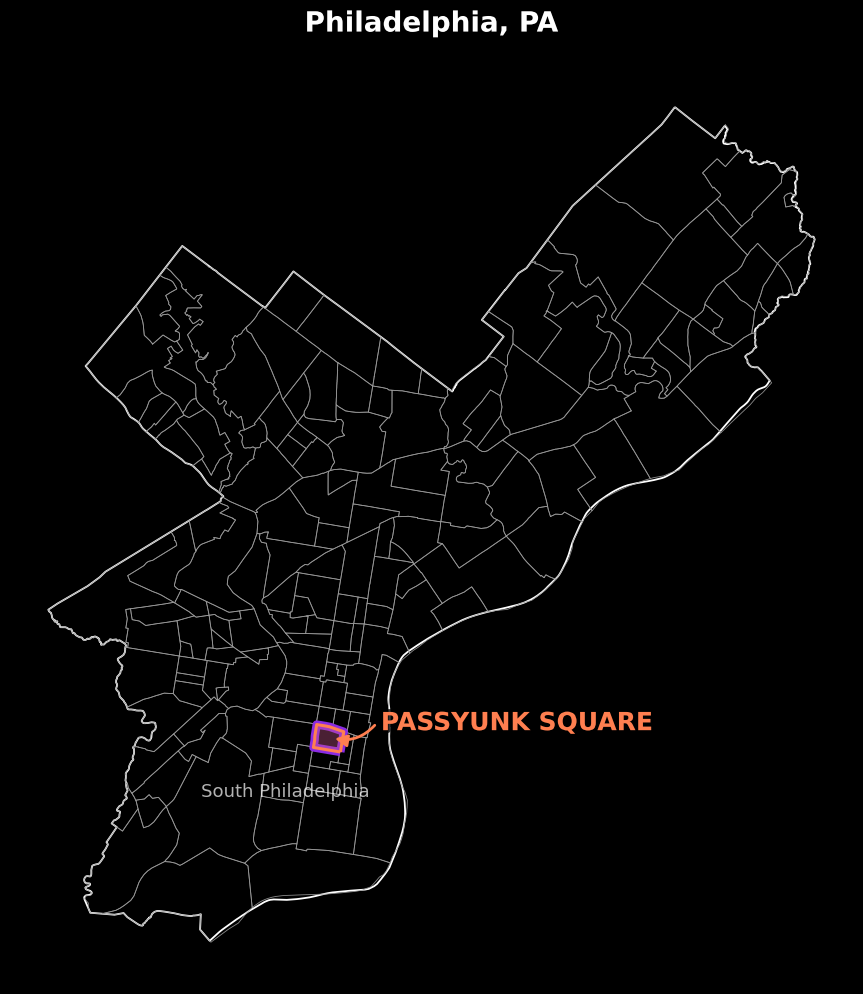

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import numpy as np
from matplotlib.patches import FancyArrowPatch

# -------------------------------
# Load and prepare data
# -------------------------------
citylimits = gpd.read_file("data/City_Limits.geojson").to_crs(3857)
neighborhoods = gpd.read_file("data/philly_neighborhoods.geojson").to_crs(3857)

# Select Passyunk Square
ep = neighborhoods[neighborhoods["NAME"] == "PASSYUNK_SQUARE"].to_crs(3857)

# Compute centroid for labeling
centroid = ep.geometry.centroid.iloc[0]


# -------------------------------
# Create figure
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")

# Slight shadow under entire city boundary (NYT style)
citylimits.boundary.plot(
    ax=ax, color="white", linewidth=1.3,
    path_effects=[PathEffects.withStroke(linewidth=4, foreground="black", alpha=0.6)]
)

# Neighborhood boundaries brighter
neighborhoods.boundary.plot(ax=ax, color="#999999", linewidth=0.6, alpha=0.9)

# -------------------------------
# Highlight Passyunk Square (dual glow)
# -------------------------------

# Purple under-glow outline
ep.plot(ax=ax, color="#8A2BE233", edgecolor="#8A2BE2", linewidth=6, zorder=3)

# Orange inner outline
ep.plot(ax=ax, color="#FF7F5035", edgecolor="#FF7F50", linewidth=2.2, zorder=4)


# -------------------------------
# Labels
# -------------------------------

# PASSYUNK SQUARE label position
label_x = centroid.x + 2500
label_y = centroid.y + 700

# Main neighborhood label
txt = ax.text(
    label_x,
    label_y,
    "PASSYUNK SQUARE",
    color="#FF7F50",
    fontsize=18,
    weight="bold",
    ha="left",
    va="center",
    zorder=10,
)
txt.set_path_effects([
    PathEffects.withStroke(linewidth=4, foreground="black", alpha=0.8)
])

# Add “South Philadelphia” region label (smaller)
ax.text(
    centroid.x - 2000,
    centroid.y - 2500,
    "South Philadelphia",
    color="white",
    fontsize=13,
    alpha=0.7,
    ha="center",
    va="center",
    zorder=9,
)


# -------------------------------
# Curved callout arrow (professional style)
# -------------------------------
arrow = FancyArrowPatch(
    posA=(label_x - 200, label_y),
    posB=(centroid.x + 200, centroid.y),
    connectionstyle="arc3,rad=-0.3",   # curve shape
    arrowstyle="-|>",
    mutation_scale=18,
    linewidth=2,
    color="#FF7F50",
    zorder=9,
)
ax.add_patch(arrow)


# -------------------------------
# Title
# -------------------------------
title = ax.text(
    0.5, 1.03,
    "Philadelphia, PA",
    transform=ax.transAxes,
    fontsize=20,
    color="white",
    weight="bold",
    ha="center",
    va="bottom",
)
title.set_path_effects([PathEffects.withStroke(linewidth=4, foreground="black", alpha=0.7)])


# -------------------------------
# Final cleanup
# -------------------------------
ax.set_axis_off()
plt.tight_layout()
plt.savefig("locator_passyunk_upgraded.png", dpi=300, facecolor="black", bbox_inches="tight")
plt.show()


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyArrowPatch

# -------------------------------
# Load & prepare data
# -------------------------------
citylimits = gpd.read_file("data/City_Limits.geojson").to_crs(3857)
neighborhoods = gpd.read_file("data/philly_neighborhoods.geojson").to_crs(3857)

# Identify regions
south_philly = neighborhoods[neighborhoods["NAME"].str.contains("PASSYUNK|GIRARD EST|WHARTON|POINT BREEZE|GRAYS", case=False)]
ep = neighborhoods[neighborhoods["NAME"] == "PASSYUNK_SQUARE"]

# Centroid of EP
ep_centroid = ep.geometry.centroid.iloc[0]

# -------------------------------
# Create figure
# -------------------------------
fig, ax = plt.subplots(figsize=(12, 12), facecolor="black")

# Main city boundary (shadow + white)
citylimits.boundary.plot(
    ax=ax, color="white", linewidth=1.4,
    path_effects=[PathEffects.withStroke(linewidth=6, foreground="black", alpha=0.5)]
)

# Neighborhood boundaries
neighborhoods.boundary.plot(ax=ax, color="#777777", linewidth=0.6)

# -------------------------------
# INSET 1 — South Philadelphia
# -------------------------------
ax_in1 = inset_axes(ax, width="30%", height="30%", loc="lower left",
                    borderpad=3, bbox_to_anchor=(0.05, 0.05, 1, 1), 
                    bbox_transform=ax.transAxes)

# Zoom area for South Philly
minx, miny, maxx, maxy = south_philly.total_bounds
ax_in1.set_xlim(minx - 800, maxx + 800)
ax_in1.set_ylim(miny - 800, maxy + 800)

# Plot South Philly region highlight
neighborhoods.boundary.plot(ax=ax_in1, color="#444444", linewidth=0.4)
south_philly.plot(ax=ax_in1, color="#8A2BE233", edgecolor="#8A2BE2", linewidth=2.5)

# Label
ax_in1.text(
    minx, maxy + 500,
    "South Philadelphia",
    color="white",
    fontsize=10,
    weight="bold",
    ha="left",
    path_effects=[PathEffects.withStroke(linewidth=3, foreground="black")]
)

ax_in1.set_axis_off()


# -------------------------------
# INSET 2 — Passyunk Square (Zoomed)
# -------------------------------
ax_in2 = inset_axes(ax, width="25%", height="25%", loc="lower left",
                    borderpad=3, bbox_to_anchor=(0.35, 0.08, 1, 1),
                    bbox_transform=ax.transAxes)

# Zoom area for Passyunk
minx2, miny2, maxx2, maxy2 = ep.total_bounds
ax_in2.set_xlim(minx2 - 300, maxx2 + 300)
ax_in2.set_ylim(miny2 - 300, maxy2 + 300)

# Plot Passyunk outline
neighborhoods.boundary.plot(ax=ax_in2, color="#444444", linewidth=0.4)
ep.plot(ax=ax_in2, color="#FF7F5035", edgecolor="#FF7F50", linewidth=3)

# Label EP inset
ax_in2.text(
    ep_centroid.x,
    ep_centroid.y,
    "Passyunk Square",
    color="#FF7F50",
    fontsize=10,
    weight="bold",
    ha="center",
    va="center",
    path_effects=[PathEffects.withStroke(linewidth=3, foreground="black")]
)

ax_in2.set_axis_off()

# -------------------------------
# Connectors — callout arrows
# -------------------------------
# Arrow from main city to South Philly inset
arrow1 = FancyArrowPatch(
    posA=(minx, miny), posB=(minx + 15000, miny + 30000),
    connectionstyle="arc3,rad=0.2",
    arrowstyle="-", linewidth=1.5, color="white"
)
ax.add_patch(arrow1)

# Arrow from South Philly inset to Passyunk inset
arrow2 = FancyArrowPatch(
    posA=(minx2, miny2),
    posB=(minx2 + 5000, miny2 + 15000),
    connectionstyle="arc3,rad=-0.2",
    arrowstyle="-", linewidth=1.5, color="#FF7F50"
)
ax.add_patch(arrow2)

# -------------------------------
# Title
# -------------------------------
title = ax.text(
    0.5, 1.03,
    "Locator Map: Philadelphia → South Philadelphia → Passyunk Square",
    transform=ax.transAxes,
    fontsize=22,
    color="white",
    ha="center",
    weight="bold",
)
title.set_path_effects([PathEffects.withStroke(linewidth=5, foreground="black", alpha=0.6)])

ax.set_axis_off()
plt.tight_layout()
plt.show()


C:\Users\astau\AppData\Local\Temp\ipykernel_31508\2947823864.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


AttributeError: 'NoneType' object has no attribute '_get_renderer'

<Figure size 1200x1200 with 3 Axes>